In [3]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.widgets import Slider, Button, CheckButtons

from scipy.signal import butter, filtfilt

In [4]:
def harmonic_with_noise(
    amplitude,
    frequency,
    phase,
    noise_mean,
    noise_covariance,
    show_noise=True
):
    t = np.linspace(0, 10, 1000)

    harmonic = amplitude * np.sin(
        2 * np.pi * frequency * t + phase
    )

    noise = np.random.normal(
        noise_mean,
        np.sqrt(noise_covariance),
        len(t)
    )

    if show_noise:
        signal = harmonic + noise
    else:
        signal = harmonic

    return t, harmonic, signal

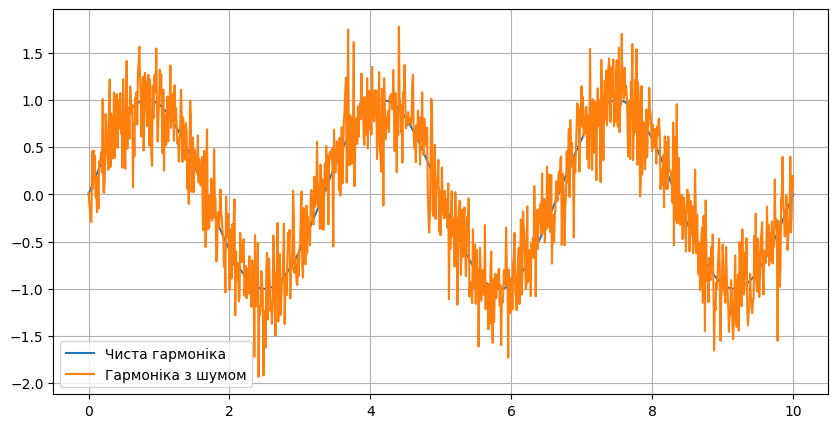

In [5]:
t, harmonic, noisy_signal = harmonic_with_noise(
    amplitude=1,
    frequency=0.3,
    phase=0,
    noise_mean=0,
    noise_covariance=0.1,
    show_noise=True
)

plt.figure(figsize=(10,5))
plt.plot(t, harmonic, label="Чиста гармоніка")
plt.plot(t, noisy_signal, label="Гармоніка з шумом")
plt.legend()
plt.grid()
plt.show()

In [6]:
def lowpass_filter(signal, cutoff=5, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    b, a = butter(order, normal_cutoff, btype='low')

    filtered = filtfilt(b, a, signal)

    return filtered

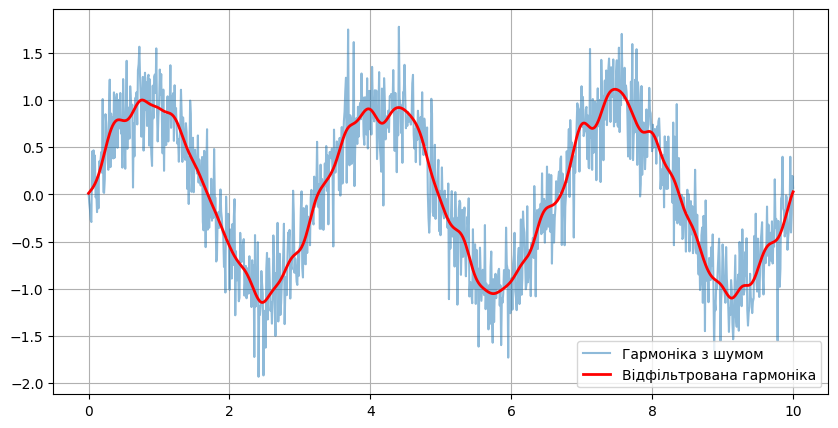

In [7]:
filtered_signal = lowpass_filter(
    noisy_signal,
    cutoff=3
)

plt.figure(figsize=(10,5))

plt.plot(
    t,
    noisy_signal,
    alpha=0.5,
    label="Гармоніка з шумом"
)

plt.plot(
    t,
    filtered_signal,
    color="red",
    linewidth=2,
    label="Відфільтрована гармоніка"
)

plt.legend()
plt.grid()
plt.show()

In [10]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

def harmonic_with_noise(amplitude, frequency, phase, noise_mean, noise_covariance, show_noise=True):
    t = np.linspace(0, 10, 1000)
    harmonic = amplitude * np.sin(2 * np.pi * frequency * t + phase)
    noise = np.random.normal(noise_mean, np.sqrt(noise_covariance), len(t))
    
    if show_noise:
        signal = harmonic + noise
    else:
        signal = harmonic
        
    return t, harmonic, signal

def lowpass_filter(signal, cutoff=5, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="low")
    return filtfilt(b, a, signal)

amplitude0 = 1
frequency0 = 0.3
phase0 = 0
noise_mean0 = 0
noise_covariance0 = 0.1
cutoff0 = 3
show_noise0 = True

t, harmonic, noisy_signal = harmonic_with_noise(
    amplitude0, frequency0, phase0,
    noise_mean0, noise_covariance0,
    show_noise0
)

filtered_signal = lowpass_filter(noisy_signal, cutoff=cutoff0)

fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(left=0.15, bottom=0.38)

line_clean, = ax.plot(t, harmonic, label="Чиста гармоніка")
line_noisy, = ax.plot(t, noisy_signal, alpha=0.5, label="Гармоніка з шумом")
line_filtered, = ax.plot(t, filtered_signal, color="red", linewidth=2, label="Відфільтрована гармоніка")

ax.set_title("Інтерактивна гармоніка з шумом та фільтрацією")
ax.set_xlabel("Час")
ax.set_ylabel("Амплітуда")
ax.grid()
ax.legend()

ax_amp = plt.axes([0.2, 0.28, 0.6, 0.03])
ax_freq = plt.axes([0.2, 0.23, 0.6, 0.03])
ax_phase = plt.axes([0.2, 0.18, 0.6, 0.03])
ax_noise_mean = plt.axes([0.2, 0.13, 0.6, 0.03])
ax_noise_cov = plt.axes([0.2, 0.08, 0.6, 0.03])
ax_cutoff = plt.axes([0.2, 0.03, 0.6, 0.03])

slider_amp = Slider(ax_amp, "Amplitude", 0.1, 3.0, valinit=amplitude0)
slider_freq = Slider(ax_freq, "Frequency", 0.1, 2.0, valinit=frequency0)
slider_phase = Slider(ax_phase, "Phase", 0, 2*np.pi, valinit=phase0)
slider_noise_mean = Slider(ax_noise_mean, "Noise Mean", -1.0, 1.0, valinit=noise_mean0)
slider_noise_cov = Slider(ax_noise_cov, "Noise Covariance", 0.0, 1.0, valinit=noise_covariance0)
slider_cutoff = Slider(ax_cutoff, "Cutoff Frequency", 0.5, 10.0, valinit=cutoff0)

ax_check = plt.axes([0.83, 0.13, 0.13, 0.08])
check = CheckButtons(ax_check, ["Show Noise"], [show_noise0])

ax_reset = plt.axes([0.83, 0.03, 0.1, 0.04])
button_reset = Button(ax_reset, "Reset")

def update(val=None):
    show_noise = check.get_status()[0]
    
    t, harmonic, signal = harmonic_with_noise(
        slider_amp.val,
        slider_freq.val,
        slider_phase.val,
        slider_noise_mean.val,
        slider_noise_cov.val,
        show_noise
    )
    
    filtered = lowpass_filter(signal, cutoff=slider_cutoff.val)
    
    line_clean.set_ydata(harmonic)
    line_noisy.set_ydata(signal)
    line_filtered.set_ydata(filtered)
    
    if show_noise:
        line_noisy.set_visible(True)
    else:
        line_noisy.set_visible(False)
        
    fig.canvas.draw_idle()

def reset(event):
    slider_amp.reset()
    slider_freq.reset()
    slider_phase.reset()
    slider_noise_mean.reset()
    slider_noise_cov.reset()
    slider_cutoff.reset()

slider_amp.on_changed(update)
slider_freq.on_changed(update)
slider_phase.on_changed(update)
slider_noise_mean.on_changed(update)
slider_noise_cov.on_changed(update)
slider_cutoff.on_changed(update)
check.on_clicked(update)
button_reset.on_clicked(reset)

plt.show()

<IPython.core.display.Javascript object>